In [1]:
import os
import pandas as pd
import xlwings as xw

In [2]:
# Definición de Var globales de accesso a archivos
CODIGO_USUARIO = os.getlogin()
DIRECTORIO_LOCAL = os.getcwd().replace("\\", "/")
BASE_SELECTION = {
    "credicorp": "Credicorp/David Alonso Cuadros Negrete - PS",
    "onedrive": "OneDrive - Credicorp/Archivos de David Alonso Cuadros Negrete - PS",
}

# Directorios de información
IMPORT_PATH_CHARTBOOK = f"D:/Datos de Usuarios/{CODIGO_USUARIO}/Credicorp/Mandatos Perú - Documents/6 - Celula de RV/2 - Monitor.xlsx"

In [3]:
def import_chartbook(open_excel: bool = False, file: str = IMPORT_PATH_CHARTBOOK) -> pd.DataFrame:
    
    """
    Importar datos desde el Excel de Chartbook de Renta Variable.
    Si el archivo está abierto en Excel, se importa directamente desde allí utilizando xlwings.
    Si no está abierto, se importa desde la ruta especificada utilizando pandas.

    Parámetros:
    ----------------
    open_excel (bool): Indica si el archivo de Excel está abierto. Por defecto es False.
    
    file (str): Ruta al archivo de Excel. Por defecto es IMPORT_PATH_CHARTBOOK

    Retorna:
    ----------------
    data (pd.DataFrame): DataFrame con los datos de precios desde la hoja "Data".
    
    activos (pd.DataFrame): DataFrame con la información de los activos desde la hoja "Base".

    """
    
    data = pd.read_excel(file, skiprows=12, usecols= lambda x: x not in ["A", "B"], sheet_name="Data", engine="openpyxl")
    data = data.set_index("Fecha")    
    activos = pd.read_excel(file, skiprows=2, usecols= lambda x: x not in ["A"], sheet_name="Base", engine="openpyxl")    
    activos = activos.drop(columns=["Unnamed: 0"])
    activos = activos.set_index("Ticker")

    return data, activos

In [4]:
data, activos = import_chartbook()

d:\Datos de Usuarios\K02066\Desktop\Helpers_PS\helpers_ps\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [2]:
from helpers_ps.Grafico.graf import Graph_mtplt
from helpers_ps.Config.var_globs import PALETA_COLORES

In [6]:
data.columns.tolist()

['PX_LAST-GSXUDEFS INDEX',
 'PX_LAST-GSXUCYCL INDEX',
 'PX_LAST-RUJ INDEX',
 'PX_LAST-RUO INDEX',
 'PX_LAST-SVX INDEX',
 'PX_LAST-SGX INDEX',
 'PX_LAST-RTY INDEX',
 'PX_LAST-SPX INDEX',
 'PX_LAST-B500XM7P INDEX',
 'PX_LAST-S5COND INDEX',
 'PX_LAST-S5CONS INDEX',
 'PX_LAST-S5ENRS INDEX',
 'PX_LAST-S5MATRX INDEX',
 'PX_LAST-S5RLST INDEX',
 'PX_LAST-S5HLTH INDEX',
 'PX_LAST-S5TELS INDEX',
 'PX_LAST-S5UTIL INDEX',
 'PX_LAST-S5INDU INDEX',
 'PX_LAST-S5FINL INDEX',
 'PX_LAST-S5INFT INDEX',
 'PX_LAST-NDX INDEX',
 'PX_LAST-VIX INDEX',
 'PX_LAST-USGG10YR INDEX',
 'PX_LAST-USGG30YR INDEX',
 'PX_LAST-USGG2YR INDEX',
 'PX_LAST-DSPX INDEX',
 'PX_LAST-INDU INDEX',
 'PX_LAST-MOVE INDEX',
 'PX_LAST-PCUSEQTR INDEX',
 'PX_LAST-IMM0ENCN INDEX',
 'PX_LAST-GU731834 INDEX',
 'PX_LAST-SKEW INDEX',
 'PX_LAST-SMILE INDEX',
 'PX_LAST-MXWD INDEX',
 'PX_LAST-RIY INDEX',
 'PX_LAST-BFCIUS INDEX',
 'PX_LAST-XAU CURNCY',
 'PX_LAST-CL1 COMDTY',
 'PX_LAST-HG1 COMDTY',
 'PX_LAST-MXCA INDEX',
 'PX_LAST-MSER INDEX',
 'PX_

In [7]:
tickers = ["PX_LAST-SPX INDEX", "PX_LAST-RUO INDEX"]
data_indices_i = data[tickers]
data_indices_i

,PX_LAST-SPX INDEX,PX_LAST-RUO INDEX
Fecha,,
1996-06-26,664.39,252.340
1996-06-27,668.55,255.000
1996-06-28,670.63,259.426
1996-06-29,670.63,259.426
1996-06-30,670.63,259.426
...,...,...
2026-06-15,7554.29,1970.114
2026-06-16,7511.35,1946.706
2026-06-17,7420.10,1939.502


In [8]:
graficos_lamina1 = {}

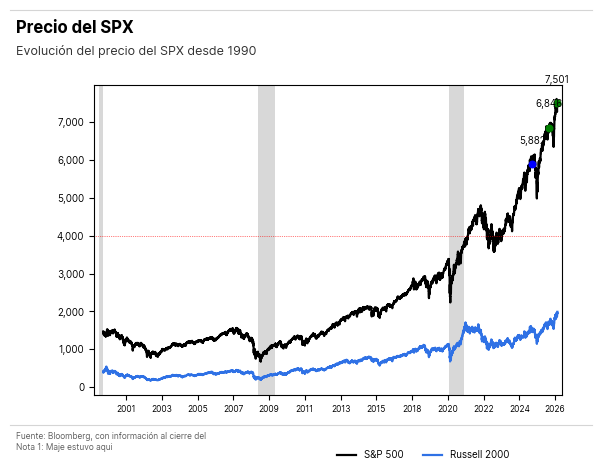

In [9]:
graph = Graph_mtplt(dataframe = data_indices_i)
graph.graph_line(
    tickers = "all",
    labels = ["S&P 500", "Russell 2000"],
    titles=dict(
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),
    source = [f"Fuente: Bloomberg, con información al cierre del","Nota 1: Maje estuvo aqui"],
    colors = ["black"],
        x_axis=dict(
        tick_step=25, 
        bbg_format=False,
        fmt="%Y",
        lim = ("2000-01-01", None),
        fontsize=6
        ),
    tag_dot={
        "1": dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = ["last", pd.Timestamp("2025-12-31")],
            template = "{y_value:,.0f}",
            show="dot_tag",
            dot_color="green",
            dot_size = 22,
        ),
        "2": dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = [pd.Timestamp("2024-12-31")],
            template = "{y_value:,.0f}",
            show="dot_tag",
            dot_color="blue",
            font_color="black",
            dot_size = 22,
        ),
    },
    legend = dict(
        show = True,
    ),
    hlines=dict(
        y_values=[4000],
        linestyle=":",
        color="red"
    )
)
graph.add_recesiones(country="Peru")
#graph.save(graficos_lamina1, name="Precio_SPX")

In [11]:
graficos_lamina1

{}

In [12]:
data_indices_j = data_indices_i.copy()
data_indices_j = data_indices_j.resample("ME").last()
data_indices_j = data_indices_j.tail(12)
data_indices_j

,PX_LAST-SPX INDEX,PX_LAST-RUO INDEX
Fecha,,
2025-07-31,6339.39,1483.003
2025-08-31,6460.26,1569.574
2025-09-30,6688.46,1634.076
2025-10-31,6840.20,1686.562
2025-11-30,6849.09,1674.164
2025-12-31,6845.50,1651.862
2026-01-31,6939.03,1717.183
2026-02-28,6878.88,1712.223
2026-03-31,6528.52,1603.373


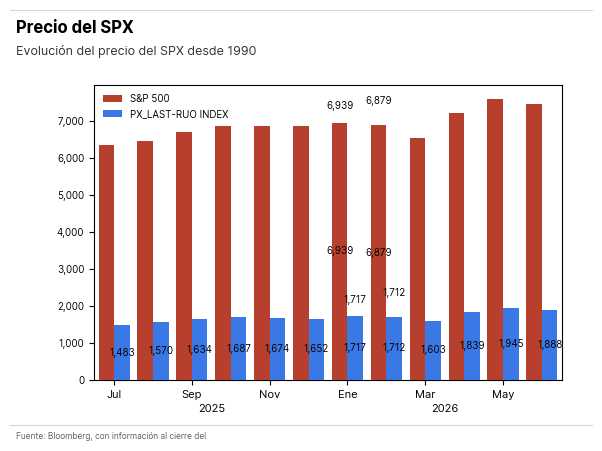

In [ ]:
graph = Graph_mtplt(dataframe = data_indices_j)
graph.graph_bar(
    tickers = "all",
    labels = ["S&P 500"],
    titles=dict(
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),
    source = [f"Fuente: Bloomberg, con información al cierre del"],
    colors = PALETA_COLORES[3],
    bar_mode = "time",
    stacked = False,
    grouped=True,
    bar_labels={
        "1": dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = ["2026-02-28", "2026-01-31"],
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,7)
        ),
        "2": dict(
            ticker="PX_LAST-RUO INDEX",
            x_values = ["2026-02-28", "2026-01-31"],
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,7)
        ),
    },
    bar_tags={
        "1": dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = ["2026-02-28", "2026-01-31"],
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,0)
        ),
        "2": dict(
            ticker="PX_LAST-RUO INDEX",
            x_values = "all",
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,0)
        ),
    },
    x_axis=dict(
        tick_step=2,
        fontsize=8,
        bbg_format=True,
        fmt="%Y-%m",
        ),
)
graph.shade_x_periods([("2026")])
#graph.etiqueta_valor(x_value="2025-10-31", y_value=1000, label="hola")

In [14]:
graph._bars_data


{'PX_LAST-SPX INDEX': {'bars': <BarContainer object of 12 artists>},
 'PX_LAST-RUO INDEX': {'bars': <BarContainer object of 12 artists>}}

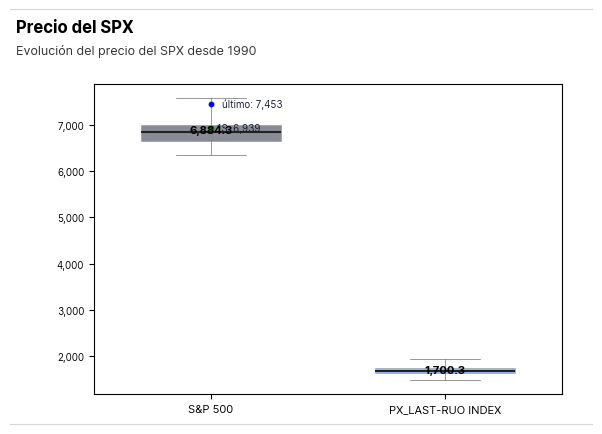

In [15]:
graph = Graph_mtplt(dataframe = data_indices_j)
graph.graph_box_whiskers(
    tickers = "all",
    labels = ["S&P 500"],
    titles=dict(
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),
    x_axis=dict(
        lim =("2023-01-01", None)
    ),
    tag_dot={
        "1":dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = "last",
            show="dot_tag",
            dot_size=10,
            dot_color = "blue",
            template="último: {y_value:,.0f}",
            ubic_etq=(30,0)
        ),
        "2":dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = ["2026-01-31"],
            show="dot_tag",
            dot_size=10,
            dot_color = "green",
            template="1S: {y_value:,.0f}"
        )
    },
    box_config=dict(
        whis=(0,100)
    ),
    range_tag_high=dict(show=False),
    range_tag_low=dict(show=False)
)
#graph.etiqueta_valor(x_value=1, y_value=4000, label="Hola", fontweight="normal")

In [3]:
df = pd.read_parquet("curve.parquet")

In [4]:
df = df.resample("ME").last()
df

,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
Date,,,,,,,,,,
1990-01-31,8.00,8.13,8.08,8.28,8.36,8.35,8.39,8.43,8.445,8.46
1990-02-28,8.04,8.14,8.12,8.43,8.45,8.44,8.54,8.51,8.525,8.54
1990-03-31,8.07,8.24,8.35,8.64,8.69,8.65,8.70,8.65,8.640,8.63
1990-04-30,8.07,8.44,8.58,8.96,9.05,9.04,9.06,9.04,9.020,9.00
1990-05-31,8.01,8.12,8.22,8.50,8.53,8.56,8.64,8.60,8.590,8.58
...,...,...,...,...,...,...,...,...,...,...
2026-02-28,3.67,3.60,3.48,3.38,3.39,3.51,3.72,3.97,4.570,4.64
2026-03-31,3.70,3.72,3.68,3.79,3.81,3.92,4.11,4.30,4.880,4.88
2026-04-30,3.68,3.71,3.72,3.88,3.91,4.02,4.20,4.40,4.970,4.98


In [5]:
new_df = df.tail(2)
new_df.index = new_df.index.strftime("%d-%B")
new_df = new_df / 100.00
cols = new_df.columns.tolist()
date = new_df.index.tolist()
new_df_2 = new_df.tail(1)
new_df_2.index = ["mtd"]
new_df_3 = new_df.head(1)
new_df_3.index = ["mtd"]
new_df_4 = (new_df_2 - new_df_3) * 10000
new_df_4


,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
mtd,8.0,0.0,3.0,7.0,3.0,4.0,4.0,1.0,-1.0,-2.0


In [6]:
new_df = df.tail(3)
new_df_5 = new_df.head(1)
new_df_6 = new_df.tail(1)
new_df_5.index = ["ytd"]
new_df_6.index = ["ytd"]
new_df_7 = (new_df_6 - new_df_5) * 10000 / 100
new_df_4 = pd.concat([new_df_4, new_df_7])
new_df_4

,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
mtd,8.0,0.0,3.0,7.0,3.0,4.0,4.0,1.0,-1.0,-2.0
ytd,9.0,7.0,10.0,17.0,18.0,15.0,11.0,6.0,0.0,-1.0


In [7]:
new_df = df.tail(2)
new_df.index = new_df.index.strftime("%d-%B")
new_df = new_df / 100.00

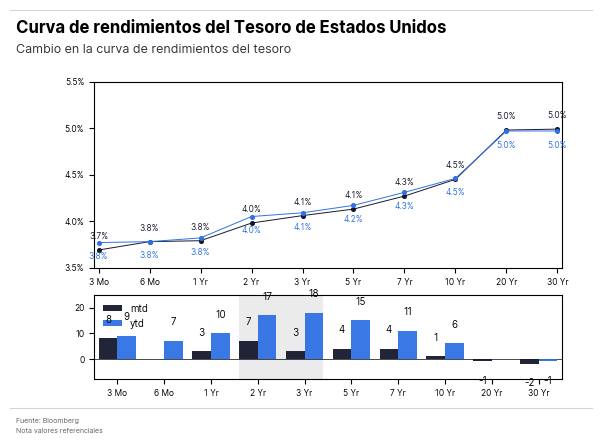

In [13]:
graph = Graph_mtplt([new_df.T,new_df_4.T])
graph.plot(nrows=2, height_ratios=[2.2, 1.0])
graph.graph_line(
    titles=dict(
        title = "Curva de rendimientos del Tesoro de Estados Unidos",
        subtitle = "Cambio en la curva de rendimientos del tesoro"
    ),
    y_axis=dict(
        fmt=".1%",
        lim=(0.035,0.055),
        fontsize=6,
        tick_step=0.005
    ),
    x_axis=dict(
        fontsize=6
    ),
    tag_dot={
        "i":dict(
            ticker = date[0],
            x_values=cols,
            show="tag_dot",
            template="{y_value:.1%}",
            ubic_etq=(0,10),
            dot_size=7,
            fontsize=6,
            font_color=PALETA_COLORES[0]
        ),
        "j":dict(
            ticker = date[1],
            x_values=cols,
            show="tag_dot",
            template="{y_value:.1%}",
            ubic_etq=(0,-10),
            dot_size=7,
            fontsize=6,
            font_color=PALETA_COLORES[1]
        )
    },
    lw=0.7,
    legend=dict(
        show=True
    )
)
graph._set_axis(1)
graph.graph_bar(
    df_index=1,
    hlines=dict(
        y_values=0,
        linestyle="-",
        color="black"
    ),
    y_axis=dict(
        lim=(-8,25),
        fontsize=6,
    ),
    x_axis=dict(
        fontsize=6
    ),
    bar_mode="last",
    stacked=False,
    grouped=True,
    bar_labels={
        "1": dict(
            ticker="ytd",
            x_values = "all",
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,-10)
        ),
        "2": dict(
            ticker="mtd",
            x_values = "all",
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,-10)
        ),
    },
    legend=dict(
        show=True,
        bbox_to_anchor=None,
        ncol=1
    )
)
graph.shade_x_periods([(3,4)])
graph.add_source(text=["Fuente: Bloomberg", "Nota valores referenciales"], fontsize=5)

In [17]:
data_frame = pd.read_excel("C:/Users/K02066/Downloads/recessions.xlsx")

In [19]:
data_frame = data_frame.set_index("recesion_id")
data_frame

,country,start_date,end_date,description
recesion_id,,,,
1,United States,1902-09-01,1904-08-01,Contracción industrial temprana
2,United States,1907-05-01,1908-06-01,Pánico bancario 1907
3,United States,1910-01-01,1912-01-01,Ajuste post crisis financiera
4,United States,1913-01-01,1914-12-01,Recesión pre WWI
5,United States,1918-08-01,1919-03-01,Fin WWI ajuste
6,United States,1920-01-01,1921-07-01,Contracción posguerra
7,United States,1923-05-01,1924-07-01,Ajuste inventarios
8,United States,1926-10-01,1927-11-01,Ajuste industrial
9,United States,1929-08-01,1933-03-01,Gran Depresión


In [20]:
data_frame.to_csv("recessions.csv")

In [2]:
import pandas as pd

df = pd.DataFrame({
    "Equity": [0.12, 0.08, -0.05],
    "Bonds": [0.03, 0.04, 0.02],
    "Commodities": [-0.01, 0.06, 0.10]
}, index=["2023", "2024", "2025"])


styled = (
    df.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", axis=None)
    .set_properties(**{
        "text-align": "center",
        "font-size": "11pt"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("font-weight", "bold"),
            ("border-bottom", "2px solid black"),
            ("text-align", "center")
        ]},
        {"selector": "caption", "props": [
            ("font-size", "14pt"),
            ("font-weight", "bold")
        ]}
    ])
)

styled



,Equity,Bonds,Commodities
2023,12.0%,3.0%,-1.0%
2024,8.0%,4.0%,6.0%
2025,-5.0%,2.0%,10.0%


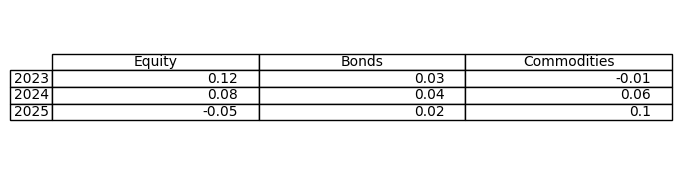

In [3]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Equity": [0.12, 0.08, -0.05],
    "Bonds": [0.03, 0.04, 0.02],
    "Commodities": [-0.01, 0.06, 0.10]
}, index=["2023", "2024", "2025"])

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis("off")

table = ax.table(
    cellText=df.round(2).values,
    rowLabels=df.index,
    colLabels=df.columns,
    loc="center"
)

plt.savefig("table.png", dpi=300, bbox_inches="tight")


In [4]:

import pandas as pd
import dataframe_image as dfi

df = pd.DataFrame({
    "Portfolio": ["Fund A", "Fund B", "Fund C"],
    "Return": [0.124, 0.086, -0.021],
    "Volatility": [0.10, 0.08, 0.12]
})

styled = (
    df.style
    .format({
        "Return": "{:.1%}",
        "Volatility": "{:.1%}"
    })
    .background_gradient(subset=["Return"], cmap="RdYlGn")
    .background_gradient(subset=["Volatility"], cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_caption("Portfolio Summary")
)

dfi.export(styled, "portfolio_summary.png", table_conversion="matplotlib")



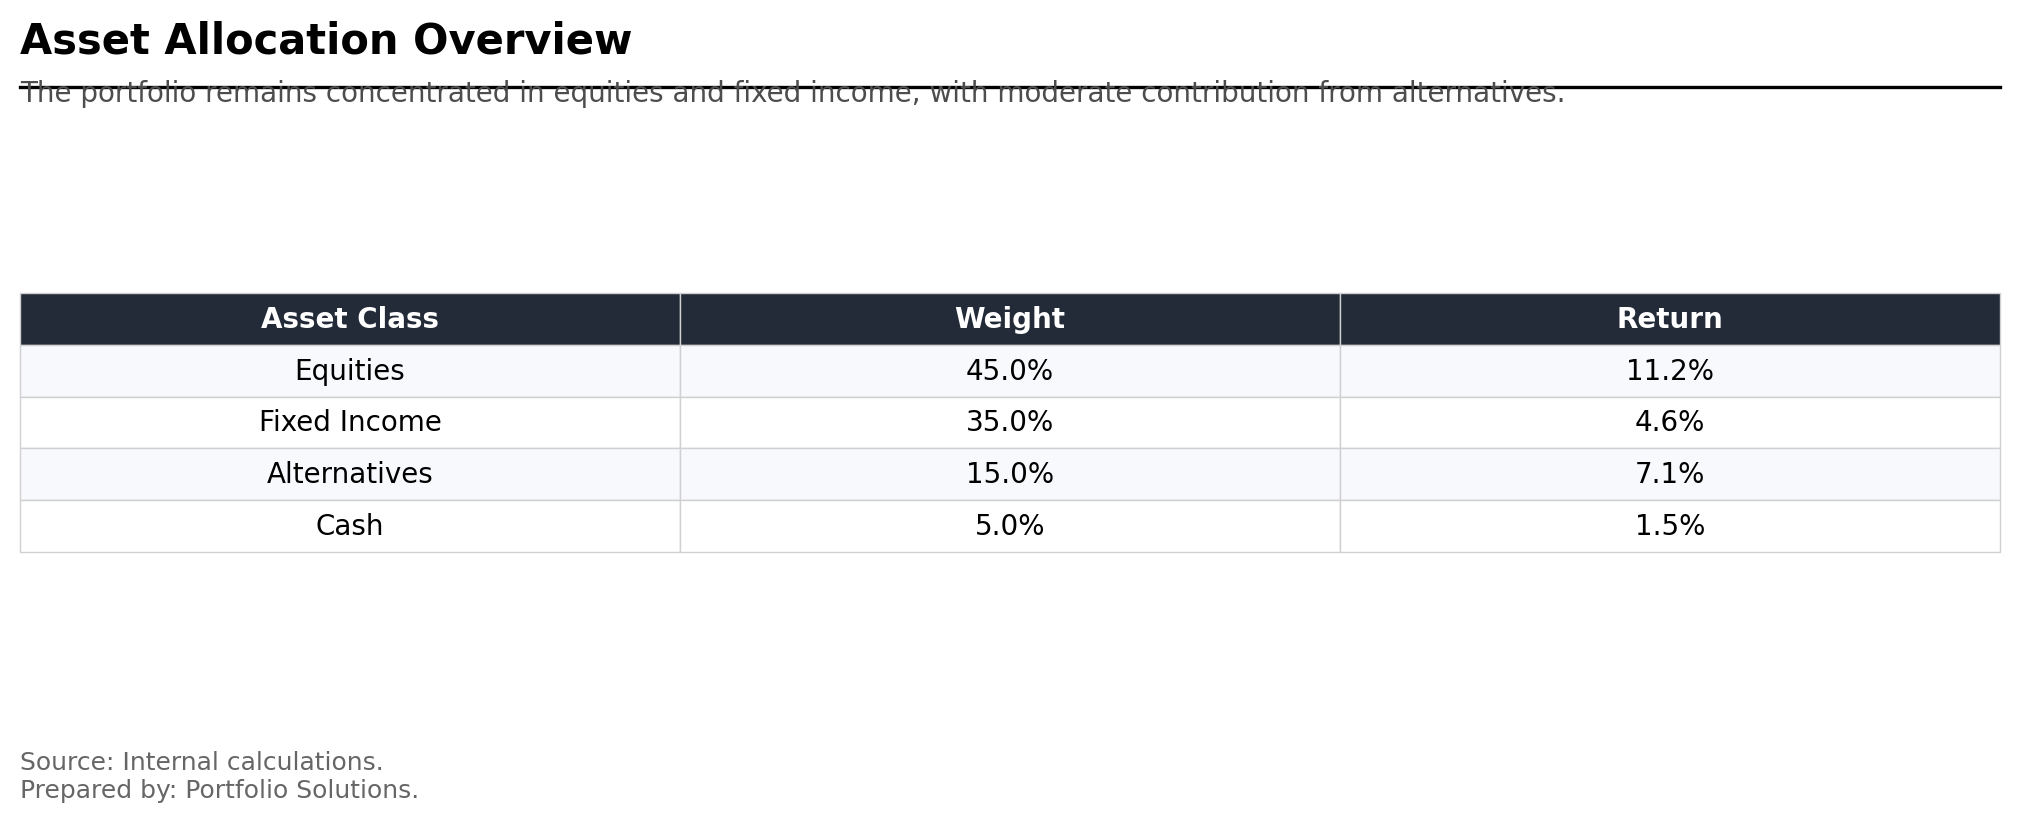

In [5]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = pd.DataFrame({
    "Asset Class": ["Equities", "Fixed Income", "Alternatives", "Cash"],
    "Weight": [0.45, 0.35, 0.15, 0.05],
    "Return": [0.112, 0.046, 0.071, 0.015]
})

df_disp = df.copy()
df_disp["Weight"] = df_disp["Weight"].map("{:.1%}".format)
df_disp["Return"] = df_disp["Return"].map("{:.1%}".format)

fig = plt.figure(figsize=(11, 4.2), dpi=200)
ax = fig.add_axes([0.05, 0.23, 0.90, 0.52])
ax.axis("off")

# Top separator line
fig.add_artist(Line2D([0.05, 0.95], [0.89, 0.89], transform=fig.transFigure,
                      color="black", linewidth=1.2))

# Table
table = ax.table(
    cellText=df_disp.values,
    colLabels=df_disp.columns,
    loc="center",
    cellLoc="center",
    colLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D0D0")
    cell.set_linewidth(0.5)

    if row == 0:
        cell.set_facecolor("#232B38")
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
    else:
        cell.set_facecolor("#F7F9FC" if row % 2 == 1 else "white")

# Titles
fig.text(0.05, 0.92, "Asset Allocation Overview",
         ha="left", va="bottom", fontsize=15, fontweight="bold")

fig.text(0.05, 0.865,
         "The portfolio remains concentrated in equities and fixed income, with moderate contribution from alternatives.",
         ha="left", va="bottom", fontsize=10, color="#4D4D4D")

# Source block
fig.text(0.05, 0.10,
         "Source: Internal calculations.\nPrepared by: Portfolio Solutions.",
         ha="left", va="top", fontsize=9, color="#666666")

fig.savefig("asset_allocation_table.png", dpi=200, bbox_inches="tight")
plt.show()


In [9]:

import pandas as pd
import numpy as np

# -----------------------------
# 1) Example data
# -----------------------------
index = [
    "Communications Services", "Real Estate", "Energy", "Utilities",
    "Consumer Discretionary", "Information Technology", "S&P500",
    "Industrials", "Health Care", "Consumer Staples", "Financials", "Materials"
]

columns = pd.MultiIndex.from_tuples([
    ("Nombre", ""),
    ("EPS Estimado", "Crecimiento 12M"),
    ("EPS Estimado", "%il ult. 20 años"),
    ("P/E Estimado", "P/E 1BF"),
    ("P/E Estimado", "%il ult. 20 años"),
    ("Potencial bottom-up", "Upside"),
    ("Potencial bottom-up", "%il ult. 20 años"),
    ("Evolución P/E 1BF 7D", "Precio"),
    ("Evolución P/E 1BF 7D", "EPS 1BF"),
    ("Evolución P/E 1BF 7D", "P/E 1BF"),
    ("Evolución P/E 1BF 30D", "Precio"),
    ("Evolución P/E 1BF 30D", "EPS 1BF"),
    ("Evolución P/E 1BF 30D", "P/E 1BF"),
    ("Score", "")
])

np.random.seed(7)

df = pd.DataFrame({
    ("Nombre", ""): index,
    ("EPS Estimado", "Crecimiento 12M"): np.random.uniform(-5, 65, len(index)),
    ("EPS Estimado", "%il ult. 20 años"): np.random.uniform(15, 98, len(index)),
    ("P/E Estimado", "P/E 1BF"): np.random.uniform(12, 38, len(index)),
    ("P/E Estimado", "%il ult. 20 años"): np.random.uniform(20, 99, len(index)),
    ("Potencial bottom-up", "Upside"): np.random.uniform(8, 25, len(index)),
    ("Potencial bottom-up", "%il ult. 20 años"): np.random.uniform(30, 98, len(index)),
    ("Evolución P/E 1BF 7D", "Precio"): np.random.uniform(-5, 5, len(index)),
    ("Evolución P/E 1BF 7D", "EPS 1BF"): np.random.uniform(-4, 4, len(index)),
    ("Evolución P/E 1BF 7D", "P/E 1BF"): np.random.uniform(-10, 10, len(index)),
    ("Evolución P/E 1BF 30D", "Precio"): np.random.uniform(-6, 9, len(index)),
    ("Evolución P/E 1BF 30D", "EPS 1BF"): np.random.uniform(-2, 8, len(index)),
    ("Evolución P/E 1BF 30D", "P/E 1BF"): np.random.uniform(-10, 10, len(index)),
    ("Score", ""): np.random.uniform(20, 65, len(index)),
}, columns=columns)

# -----------------------------
# 2) Formatting helpers
# -----------------------------
pct_cols = [
    ("EPS Estimado", "Crecimiento 12M"),
    ("EPS Estimado", "%il ult. 20 años"),
    ("P/E Estimado", "%il ult. 20 años"),
    ("Potencial bottom-up", "Upside"),
    ("Potencial bottom-up", "%il ult. 20 años"),
    ("Evolución P/E 1BF 7D", "Precio"),
    ("Evolución P/E 1BF 7D", "EPS 1BF"),
    ("Evolución P/E 1BF 7D", "P/E 1BF"),
    ("Evolución P/E 1BF 30D", "Precio"),
    ("Evolución P/E 1BF 30D", "EPS 1BF"),
    ("Evolución P/E 1BF 30D", "P/E 1BF"),
    ("Score", "")
]

pe_cols = [
    ("P/E Estimado", "P/E 1BF")
]

def fmt_pct(x):
    return f"{x:.1f}%"

def fmt_pe(x):
    return f"{x:.2f}"

format_dict = {c: fmt_pct for c in pct_cols}
format_dict.update({c: fmt_pe for c in pe_cols})

# -----------------------------
# 3) Color helpers
# -----------------------------
# red-green text for signed performance columns
signed_cols = [
    ("Evolución P/E 1BF 7D", "Precio"),
    ("Evolución P/E 1BF 7D", "EPS 1BF"),
    ("Evolución P/E 1BF 7D", "P/E 1BF"),
    ("Evolución P/E 1BF 30D", "Precio"),
    ("Evolución P/E 1BF 30D", "EPS 1BF"),
    ("Evolución P/E 1BF 30D", "P/E 1BF")
]

def color_signed(val):
    if pd.isna(val):
        return ""
    if val > 0:
        return "color: green;"
    elif val < 0:
        return "color: red;"
    return "color: black;"

# soft heatmap colors closer to your screenshot
def bg_percentile_red_green(s):
    """
    Low = green, High = red
    Useful for percentiles if high percentile means expensive / stretched.
    """
    s = pd.to_numeric(s, errors="coerce")
    vmin, vmax = s.min(), s.max()
    if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
        return ["background-color: #f2f2f2;" for _ in s]

    styles = []
    for v in s:
        if pd.isna(v):
            styles.append("background-color: #f2f2f2;")
            continue

        t = (v - vmin) / (vmax - vmin)  # 0 to 1
        # interpolate between soft green and soft red
        # green: #b7d7c0 ; neutral: #f2f2f2 ; red: #ef8f8f
        if t <= 0.5:
            # green -> neutral
            alpha = t / 0.5
            c1 = np.array([183, 215, 192])
            c2 = np.array([242, 242, 242])
        else:
            # neutral -> red
            alpha = (t - 0.5) / 0.5
            c1 = np.array([242, 242, 242])
            c2 = np.array([239, 143, 143])

        rgb = (c1 + (c2 - c1) * alpha).astype(int)
        styles.append(f"background-color: rgb({rgb[0]}, {rgb[1]}, {rgb[2]});")
    return styles

def bg_score_red_green(s):
    """
    Low score = red, high score = green
    """
    s = pd.to_numeric(s, errors="coerce")
    vmin, vmax = s.min(), s.max()

    if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
        return ["background-color: #f2f2f2;" for _ in s]

    styles = []
    for v in s:
        if pd.isna(v):
            styles.append("background-color: #f2f2f2;")
            continue

        t = (v - vmin) / (vmax - vmin)
        # low red -> neutral -> high green
        if t <= 0.5:
            alpha = t / 0.5
            c1 = np.array([239, 143, 143])
            c2 = np.array([242, 242, 242])
        else:
            alpha = (t - 0.5) / 0.5
            c1 = np.array([242, 242, 242])
            c2 = np.array([183, 215, 192])

        rgb = (c1 + (c2 - c1) * alpha).astype(int)
        styles.append(f"background-color: rgb({rgb[0]}, {rgb[1]}, {rgb[2]});")
    return styles

# -----------------------------
# 4) Base cell styles
# -----------------------------
base_td = {
    "selector": "td",
    "props": [
        ("background-color", "#efefef"),
        ("color", "black"),
        ("border", "1px solid #d0d0d0"),
        ("text-align", "center"),
        ("padding", "4px 6px"),
        ("font-size", "11px"),
        ("font-family", "Arial, sans-serif"),
        ("white-space", "nowrap"),
    ]
}

base_th = {
    "selector": "th",
    "props": [
        ("border", "1px solid black"),
        ("text-align", "center"),
        ("padding", "6px 8px"),
        ("font-size", "11px"),
        ("font-family", "Arial, sans-serif"),
        ("color", "white"),
    ]
}

# top-level headers
level0_header = {
    "selector": "th.col_heading.level0",
    "props": [
        ("background-color", "#123d8b"),
        ("font-weight", "bold"),
        ("height", "48px"),
        ("font-size", "14px"),
    ]
}

# second-level headers
level1_header = {
    "selector": "th.col_heading.level1",
    "props": [
        ("background-color", "#123d8b"),
        ("font-weight", "bold"),
        ("height", "30px"),
        ("font-size", "12px"),
    ]
}

# hide default index
hide_index_css = {
    "selector": ".row_heading, .blank",
    "props": [("display", "none")]
}

# -----------------------------
# 5) Section separator helper
# -----------------------------
# add thick left border to the first column of each big block
separator_cols = [
    ("EPS Estimado", "Crecimiento 12M"),
    ("P/E Estimado", "P/E 1BF"),
    ("Potencial bottom-up", "Upside"),
    ("Evolución P/E 1BF 7D", "Precio"),
    ("Evolución P/E 1BF 30D", "Precio"),
    ("Score", "")
]

def add_section_borders(data):
    out = pd.DataFrame("", index=data.index, columns=data.columns)
    for col in separator_cols:
        if col in out.columns:
            out[col] = out[col] + "border-left: 1.5px solid black;"
    # first label column also with strong border
    out[("Nombre", "")] = "border-left: 1.5px solid black;"
    return out

# -----------------------------
# 6) Build styler
# -----------------------------
styler = (
    df.style
    .format(format_dict)
    .hide(axis="index")
    .set_table_styles([
        base_td,
        base_th,
        level0_header,
        level1_header,
        hide_index_css,
        {"selector": "table", "props": [
            ("border-collapse", "collapse"),
            ("border", "1.5px solid black"),
            ("font-size", "8px")
        ]},
        # make Score group header red
        {"selector": "th.col_heading.level0.col13", "props": [
            ("background-color", "#b5311f"),
            
        ]},
        {"selector": "th.col_heading.level1.col13", "props": [
            ("background-color", "#b5311f")
        ]},
    ], overwrite=False)
    .apply(bg_percentile_red_green, subset=[("EPS Estimado", "%il ult. 20 años")], axis=0)
    .apply(bg_percentile_red_green, subset=[("P/E Estimado", "%il ult. 20 años")], axis=0)
    .apply(bg_percentile_red_green, subset=[("Potencial bottom-up", "%il ult. 20 años")], axis=0)
    .apply(bg_score_red_green, subset=[("Score", "")], axis=0)
)

styler
